In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

In [34]:


df = pd.read_csv(r'../../../Datasets/titanic.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [35]:
df = df[['Age', 'Fare', 'Survived']]

df

,Age,Fare,Survived
0,34.5,7.8292,0
1,47.0,7.0000,1
2,62.0,9.6875,0
3,27.0,8.6625,0
4,22.0,12.2875,1
...,...,...,...
413,NaN,8.0500,0
414,39.0,108.9000,1
415,38.5,7.2500,0
416,NaN,8.0500,0


In [36]:
df.isnull().mean()

Age         0.205742
Fare        0.002392
Survived    0.000000
dtype: float64

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Survived']), df['Survived'], test_size=0.2, random_state=False)

In [38]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [39]:
# X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = 
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum(), random_state=42).values
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = X_test['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum(), random_state=42).values

In [40]:
X_test

,Age,Fare,Age_imputed
360,14.5,69.5500,14.5
170,NaN,7.5500,22.0
224,53.0,27.4458,53.0
358,NaN,7.7500,20.0
309,45.0,14.1083,45.0
...,...,...,...
100,43.0,55.4417,43.0
7,26.0,29.0000,26.0
22,NaN,31.6833,22.0
68,31.0,28.5375,31.0


<Axes: xlabel='Age', ylabel='Count'>

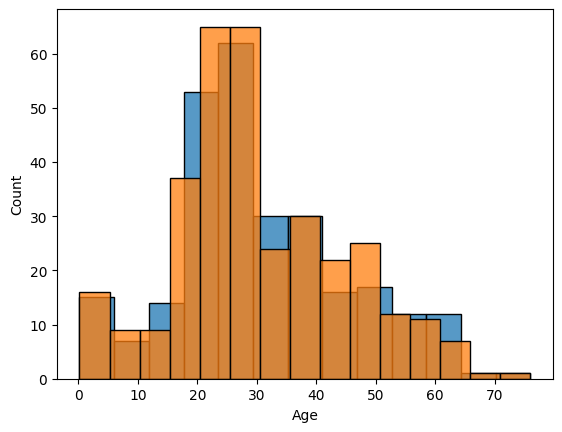

In [41]:
sns.histplot(X_train['Age'], legend='Original')
sns.histplot(X_train['Age_imputed'], legend='Imputed')

In [42]:
print('varian original: ', X_train['Age'].var())
print('varian imputed: ', X_train['Age_imputed'].var())

varian original:  217.1999017210519
varian imputed:  210.97568553703402
